
# Visualizing Excel Model Logic with Python

This notebook expands on the model auditing script.

Goals:

• Build a dependency graph of an Excel model  
• Highlight structural violations (hardcoded constants)  
• Ensure disconnected cells still appear in the graph  
• Produce a clearer layered visualization  
• Create a simplified block‑level architecture diagram


## Install libraries (if needed)

In [1]:

# !pip install openpyxl networkx matplotlib


## Import libraries

In [2]:

import openpyxl
import networkx as nx
import matplotlib.pyplot as plt
import re
from openpyxl.utils.cell import coordinate_from_string, column_index_from_string
from openpyxl.utils import get_column_letter


## Load workbook

In [3]:

file = "demo_financial_model.xlsx"
wb = openpyxl.load_workbook(file, data_only=False)
print("Sheets:", wb.sheetnames)


Sheets: ['Inputs', 'Calculations', 'Outputs']


## Detect hardcoded constants outside Inputs sheet

In [4]:

hardcoded_cells = set()
input_sheets = ["Inputs"]

for sheet in wb.sheetnames:
    ws = wb[sheet]

    for row in ws.iter_rows():
        for cell in row:

            if cell.data_type == "n":
                if sheet not in input_sheets:
                    if cell.value is not None:
                        hardcoded_cells.add(f"{sheet}!{cell.coordinate}")

print("Hardcoded cells:", hardcoded_cells)


Hardcoded cells: {'Calculations!A3', 'Calculations!A4', 'Calculations!A2', 'Calculations!C2'}


## Expand Excel ranges

In [5]:

def expand_range(sheet, start, end):

    col1, row1 = coordinate_from_string(start)
    col2, row2 = coordinate_from_string(end)

    col1_i = column_index_from_string(col1)
    col2_i = column_index_from_string(col2)

    cells = []

    for col in range(col1_i, col2_i + 1):
        for row in range(row1, row2 + 1):
            coord = f"{get_column_letter(col)}{row}"
            cells.append(f"{sheet}!{coord}")

    return cells


## Build dependency graph

In [6]:

G = nx.DiGraph()

cell_pattern = r"[A-Za-z_]+!\$?[A-Za-z]+\$?\d+"
range_pattern = r"([A-Za-z_]+)!([A-Za-z]+\d+):([A-Za-z]+\d+)"

for sheet in wb.sheetnames:
    ws = wb[sheet]

    for row in ws.iter_rows():
        for cell in row:

            location = f"{sheet}!{cell.coordinate}"

            if cell.data_type == "f":

                formula = cell.value

                ranges = re.findall(range_pattern, formula)

                for r in ranges:
                    rng_sheet, start, end = r
                    expanded = expand_range(rng_sheet, start, end)

                    for ref in expanded:
                        G.add_edge(ref, location)

                refs = re.findall(cell_pattern, formula)

                for ref in refs:
                    ref = ref.replace("$","")
                    G.add_edge(ref, location)

# Ensure hardcoded cells appear
for cell in hardcoded_cells:
    if cell not in G:
        G.add_node(cell)

print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))


Nodes: 19
Edges: 10


## Color nodes

In [7]:

def node_color(node):

    if node in hardcoded_cells:
        return "gold"

    if node.startswith("Inputs"):
        return "lightgreen"

    elif node.startswith("Calculations"):
        return "lightskyblue"

    elif node.startswith("Outputs"):
        return "salmon"

    return "lightgray"

colors = [node_color(n) for n in G.nodes]


## Layered layout

In [8]:

layers = {
    "Inputs": 0,
    "Calculations": 1,
    "Outputs": 2
}

pos = {}
y_positions = {}

for node in sorted(G.nodes):

    sheet = node.split("!")[0]
    layer = layers.get(sheet, 3)

    y_positions.setdefault(sheet, 0)

    pos[node] = (layer, -y_positions[sheet])
    y_positions[sheet] += 1


## Visualize dependency graph

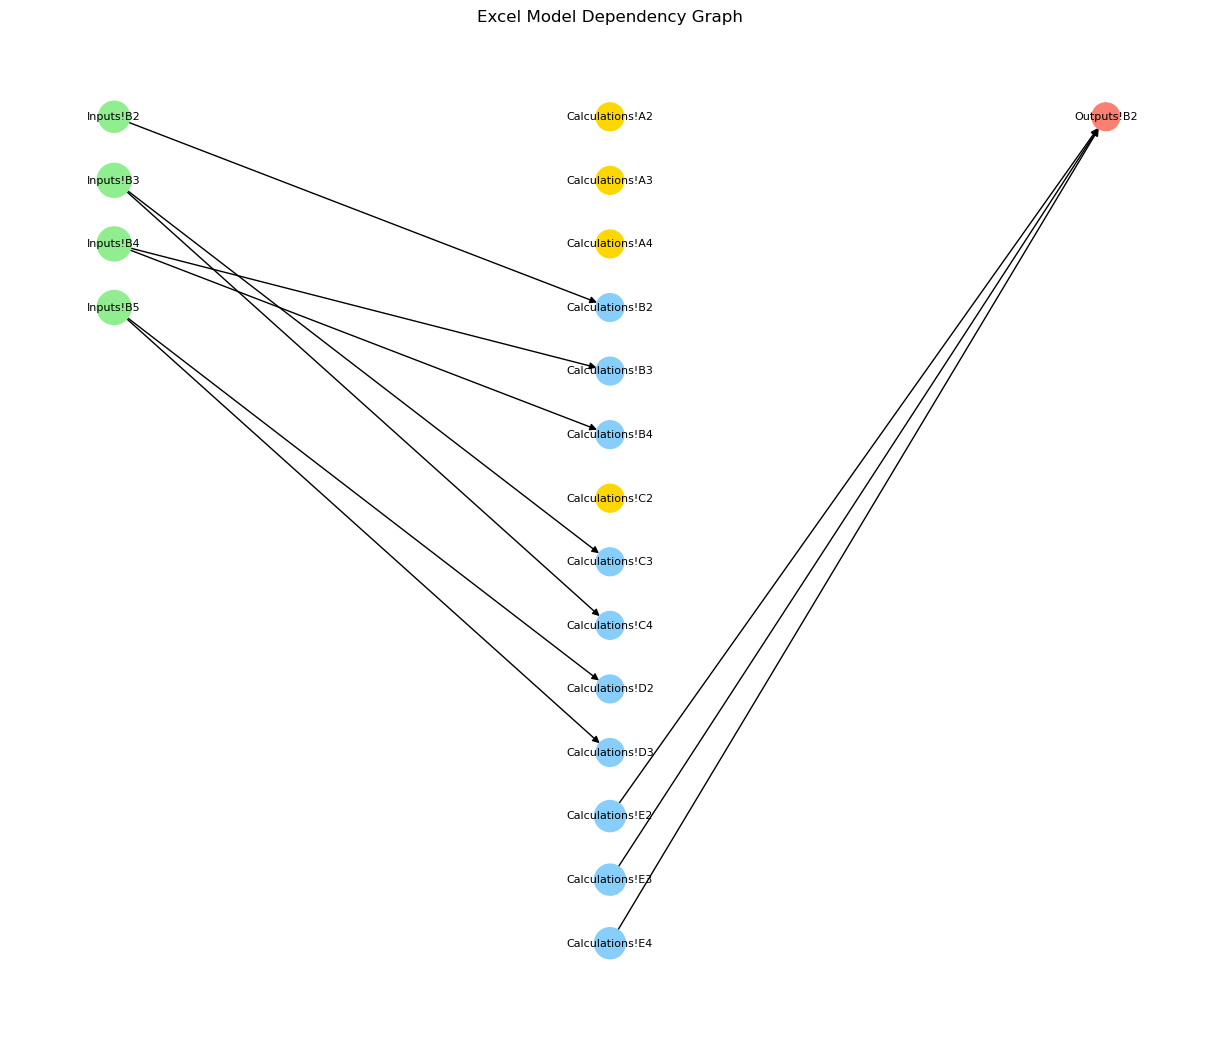

In [9]:

plt.figure(figsize=(12,10))

sizes = [400 + len(nx.descendants(G,n))*100 for n in G.nodes]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=sizes,
    font_size=8,
    arrows=True
)

plt.title("Excel Model Dependency Graph")
plt.show()


## Identify orphan cells

In [10]:

orphans = [n for n in G.nodes if G.degree(n) == 0]
print("Orphan cells:", orphans)


Orphan cells: ['Calculations!A3', 'Calculations!A4', 'Calculations!A2', 'Calculations!C2']
